In [27]:
# Importa a biblioteca pandas para manipulação de dados em DataFrames
import pandas as pd

# Importa a biblioteca numpy para operações numéricas
import numpy as np

# Importa a função para modelos lineares do statsmodels usando fórmulas
import statsmodels.formula.api as smf

# Importa seaborn para visualização de dados estatísticos
import seaborn as sns

# Importa o módulo pyplot do matplotlib para criação de gráficos
import matplotlib.pyplot as plt

# Importa a API principal do statsmodels para análise estatística
import statsmodels.api as sm

# Importa função para dividir os dados em treino e teste
from sklearn.model_selection import train_test_split

# Importa a função para cálculo do VIF (Variance Inflation Factor)
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant

import unicodedata


In [28]:
# Lê o arquivo CSV com os dados de previsão de renda
previsao_renda = pd.read_csv('./Dataset/previsao_de_renda_II.csv')

# Preenche valores ausentes na coluna 'tempo_emprego' com a média dessa coluna
previsao_renda.loc[previsao_renda['tempo_emprego'].isna(), 'tempo_emprego'] = previsao_renda.tempo_emprego.mean()

# Define a variável dependente (target) como a coluna 'renda'
y = previsao_renda['renda']

# Define as variáveis independentes removendo a coluna 'renda'
X = previsao_renda.drop(columns=['renda'])

# Separa os dados em treino e teste (60% treino, 40% teste, com semente fixa para reprodutibilidade)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=100)

# Junta as variáveis independentes e dependente para formar o dataframe de treino
df_treino = X_train.join(y_train)

# Junta as variáveis independentes e dependente para formar o dataframe de teste
df_teste = X_test.join(y_test)

# Seleciona uma amostra de 30.000 linhas do conjunto de treino para análise de resíduos
df_resid_check = df_treino.sample(30000, random_state=100).reset_index(drop=True)



In [29]:
C1 = 10.815068
C2 =  3.5
C3 = 45


### CRIANDO DOIS SEGMENTOS PARA A VARIÁVEL TEMPO_EMPREGO
# Cria a variável segmentada X1_1: igual a X1 se X1 <= C1, senão igual a C1
df_resid_check['X1_1'] = (df_resid_check['tempo_emprego'] <= C1) * df_resid_check['tempo_emprego'] + (df_resid_check['tempo_emprego'] > C1) * C1

# Cria a variável segmentada X1_2: igual a X1 - C1 se X1 > C1, senão zero
df_resid_check['X1_2'] = (df_resid_check['tempo_emprego'] > C1) * (df_resid_check['tempo_emprego'] - C1)


### CRIANDO DOIS SEGMENTOS PARA QTD_FILHOS
# Cria a variável segmentada X2_1: igual a qtd_filhos se qtd_filhos <= C2, senão igual a C2
df_resid_check['X2_1'] = (df_resid_check['qtd_filhos'] <= C2) * df_resid_check['qtd_filhos'] + (df_resid_check['qtd_filhos'] > C2) * C2

# Cria a variável segmentada X1_2: igual a qtd_filhos - C2 se X1 > C2, senão zero
df_resid_check['X2_2'] = (df_resid_check['qtd_filhos'] > C2) * (df_resid_check['qtd_filhos'] - C2)


### CRIANDO DOIS SEGMENTOS PARA A VARIÁVEL IDADE
# Cria a variável segmentada X3_1: igual a idade se idade <= C3, senão igual a C3
df_resid_check['X3_1'] = (df_resid_check['idade'] <= C3) * df_resid_check['idade'] + (df_resid_check['idade'] > C3) * C3

# Cria a variável segmentada X1_2: igual a X1 - C3 se X1 > C3, senão zero
df_resid_check['X3_2'] = (df_resid_check['idade'] > C3) * (df_resid_check['idade'] - C3)

In [30]:
# Ajusta o modelo de regressão linear segmentado usando transformações logarítmicas nas variáveis segmentadas
res_segmentada = smf.ols(
    'I(np.log(renda+1)) ~ I(np.log(X1_1 + 2)) + I(np.log(X1_2 + 2)) + I(np.log(X2_1 + 2)) + I(np.log(X2_2 + 2)) + I(np.log(X3_1 + 2))  + I(np.log(X3_2 + 2))',
    data=df_resid_check
).fit()

In [31]:
y_pred = res_segmentada.predict(df_resid_check[['X1_1', 'X1_2', 'X2_1', 'X2_2', 'X3_1', 'X3_2']])

In [32]:
res_segmentada.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     I(np.log(renda + 1))   R-squared:                       0.370
Model:                              OLS   Adj. R-squared:                  0.370
Method:                   Least Squares   F-statistic:                     2938.
Date:                  Fri, 11 Jul 2025   Prob (F-statistic):               0.00
Time:                          22:20:52   Log-Likelihood:                -43052.
No. Observations:                 30000   AIC:                         8.612e+04
Df Residuals:                     29993   BIC:                         8.618e+04
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               5.9084      0.226     26.130      0.000       5.465       6.352
I(np.log(X1_1 + 2))     0.6591      0.014     47.033      0.000       0.632       0.687
I(np.log(X1_2 + 2))     1.0123      0.012     87.519      0.000       0.990       1.035
I(np.log(X2_1 + 2))    -0.0066      0.026     -0.257      0.797      -0.057       0.044
I(np.log(X2_2 + 2))     0.2765      0.232      1.194      0.232      -0.177       0.730
I(np.log(X3_1 + 2))     0.2027      0.046      4.419      0.000       0.113       0.293
I(np.log(X3_2 + 2))    -0.0633      0.009     -6.922      0.000      -0.081      -0.045
==============================================================================
Omnibus:                      140.653   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              103.438
Skew:                          -0.021   Prob(JB):                     3.46e-23
Kurtosis:                       2.715   Cond. No.                         244.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Outliers

Avalie os *studentized residuals*, verifique se há pontos que parecem ser discrepantes.

Avalie se há pontos influentes.

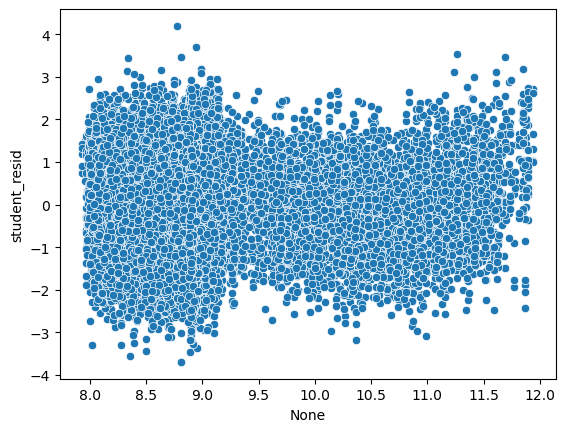

In [33]:
st_res = res_segmentada.outlier_test()
sns.scatterplot(x = y_pred, y = st_res.student_resid);

In [34]:
df_resid_check

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,X1_1,X1_2,X2_1,X2_2,X3_1,X3_2
0,2015-02-01,5770,F,S,N,0,Pensionista,Médio,Solteiro,Casa,63,7.746165,1.0,2199.86,7.746165,-0.000000,0.0,-0.0,45,18
1,2015-09-01,1403,F,N,S,0,Pensionista,Médio,Casado,Casa,58,7.746165,2.0,23220.92,7.746165,-0.000000,0.0,-0.0,45,13
2,2015-12-01,16212,F,N,S,0,Servidor público,Superior completo,Casado,Casa,34,9.465753,2.0,9440.31,9.465753,-0.000000,0.0,-0.0,34,0
3,2016-01-01,2703,F,N,S,0,Assalariado,Médio,Casado,Casa,48,10.731507,2.0,2278.68,10.731507,-0.000000,0.0,-0.0,45,3
4,2015-11-01,6122,M,S,S,0,Assalariado,Superior completo,Casado,Casa,29,1.495890,2.0,754.09,1.495890,-0.000000,0.0,-0.0,29,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,2015-07-01,12756,M,N,S,1,Servidor público,Superior completo,Casado,Casa,29,6.452055,3.0,31248.16,6.452055,-0.000000,1.0,-0.0,29,0
29996,2015-07-01,14969,F,N,S,0,Pensionista,Médio,Casado,Casa,58,7.746165,2.0,23529.12,7.746165,-0.000000,0.0,-0.0,45,13
29997,2015-04-01,6532,M,S,S,0,Assalariado,Superior completo,Casado,Casa,45,18.926027,2.0,27901.51,10.815068,8.110959,0.0,-0.0,45,0
29998,2015-08-01,4995,M,S,S,1,Assalariado,Superior completo,Casado,Casa,32,10.638356,3.0,92383.54,10.638356,-0.000000,1.0,-0.0,32,0


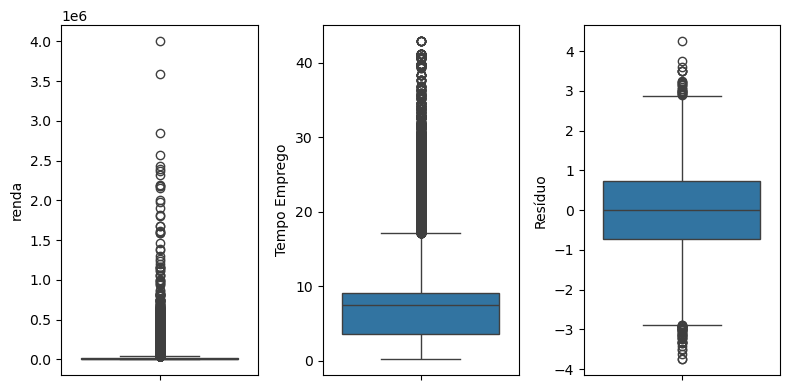

In [35]:
fig, ax = plt.subplots(1,3, figsize=(8,4))


sns.boxplot(y='renda', data=df_resid_check, ax=ax[0])
sns.boxplot(y='tempo_emprego', data=df_resid_check, ax=ax[1])
sns.boxplot(y=res_segmentada.resid, data=df_resid_check, ax=ax[2])

ax[0].set_ylabel('renda')
ax[1].set_ylabel('Tempo Emprego')
ax[2].set_ylabel('Resíduo');

plt.tight_layout()

In [36]:
influence = res_segmentada.get_influence()
summary_inf = influence.summary_frame()

# Define critérios
outlier_condition = (
    (np.abs(summary_inf["student_resid"]) > 3) |
    (summary_inf["cooks_d"] > 4 / len(df_treino))
)

# Descobre os valores "extremos"
df_outliers = df_resid_check[outlier_condition]


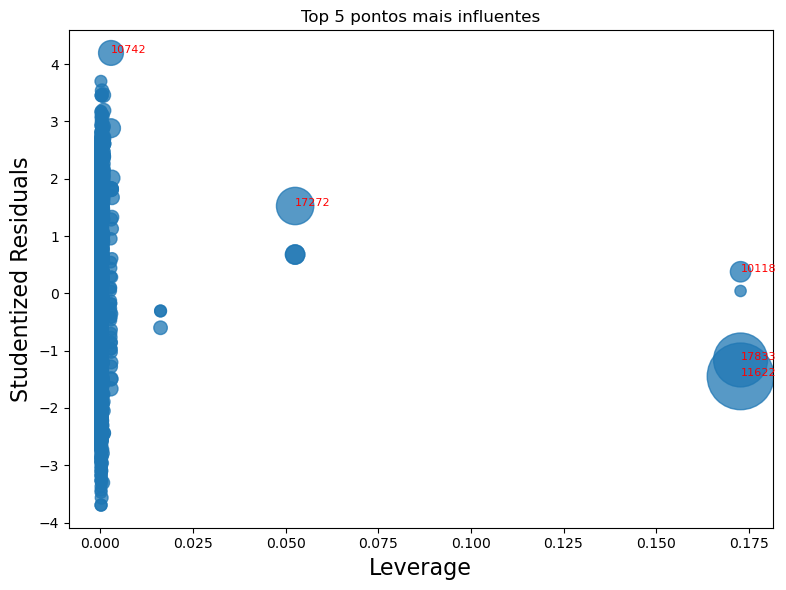

In [37]:
from statsmodels.graphics.regressionplots import influence_plot

# Calcula influência
influence = res_segmentada.get_influence()
summary_frame = influence.summary_frame()
top_points = summary_frame.sort_values("cooks_d", ascending=False).head(5)

# Plot básico
fig, ax = plt.subplots(figsize=(8, 6))
influence_plot(res_segmentada, ax=ax, criterion="cooks", alpha=0.5, labels=None)

for text in ax.texts:
    text.set_visible(False)

# Adiciona apenas os 5 pontos mais influentes
for i in top_points.index:
    x = influence.hat_matrix_diag[i]
    y = influence.resid_studentized_external[i]
    ax.annotate(i, (x, y), fontsize=8, color='red')

plt.title("Top 5 pontos mais influentes")
plt.tight_layout()
plt.show()


In [38]:
top_points

,dfb_Intercept,dfb_I(np.log(X1_1 + 2)),dfb_I(np.log(X1_2 + 2)),dfb_I(np.log(X2_1 + 2)),dfb_I(np.log(X2_2 + 2)),dfb_I(np.log(X3_1 + 2)),dfb_I(np.log(X3_2 + 2)),cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
11622,0.466119,0.002428,0.001004,0.029798,-0.660770,-0.000522,0.003372,0.062580,-1.448192,0.172783,-0.661861,-1.448218,-0.661874
17833,0.374038,0.001949,0.000806,0.023912,-0.530236,-0.000419,0.002706,0.040298,-1.162119,0.172783,-0.531118,-1.162125,-0.531122
17272,-0.252128,-0.000299,-0.001458,-0.005060,0.357400,-0.000981,-0.003416,0.018401,1.524092,0.052538,0.358895,1.524126,0.358903
10742,-0.134571,0.002039,-0.001965,0.059662,0.204872,-0.023294,0.022032,0.007138,4.193346,0.002833,0.223525,4.194506,0.223587
10118,-0.121296,-0.000632,-0.000261,-0.007754,0.171950,0.000136,-0.000877,0.004238,0.376870,0.172783,0.172239,0.376864,0.172237


In [39]:
# linhas_outliers_tempo_emprego = [4253,17798, 1401]
# df_resid_check.loc[linhas_outliers_tempo_emprego]

In [40]:
# df_resid_check = df_resid_check.loc[df_resid_check['X1'] < 40.78]